In [1]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

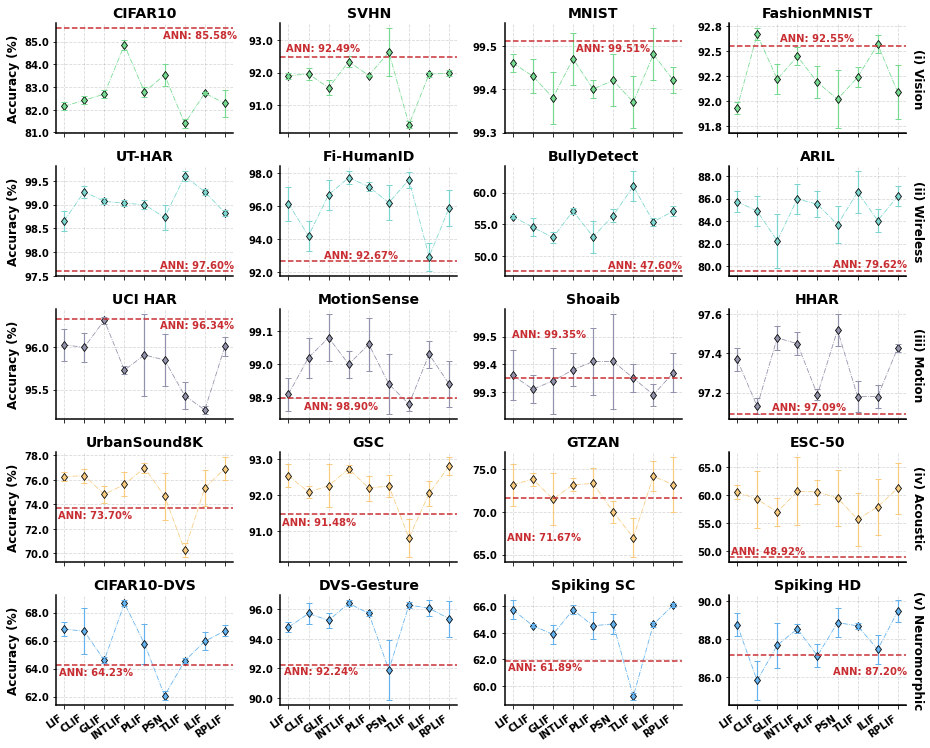

In [2]:
fig, axs = plt.subplots(5, 4, figsize=(13, 10.5))
categories = ['ANN', 'LIF', 'CLIF', 'GLIF', 'INTLIF', 'PLIF', 'PSN', 'TLIF', 'ILIF', 'RPLIF']
x = np.arange(len(categories))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
modality_colors = ['#76da91', '#f8cb7f', '#9192ab', '#7cd6cf', '#63b2ee'] # ['#002c53', '#007f54', '#0c84c6', '#2455a4', '#625ba1']
for i in range(5):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
        
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        # axs[i].set_yticks([])
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # 设置x label，只有最后一层显示
        axs[i][j].set_xticks(x[1:])
        if i == 4:
            axs[i][j].set_xticklabels(categories[1:], rotation=35, ha='right')
            # for idx, tick in enumerate(axs[i][j].get_xticklabels()):
            #     if idx == 0:
            #         tick.set_color('#c82d31')
            #     else:
            #         tick.set_color('#194f97')
        else:
            axs[i][j].set_xticklabels([])

# (a) vision sensing
line_color = modality_colors[0]
# cifar10
axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
mean_accs = [85.58, 82.15, 82.42, 82.69, 84.85, 82.79, 83.53, 81.40, 82.73, 82.28]
std_accs = [0.17, 0.17, 0.18, 0.18, 0.21, 0.21, 0.50, 0.21, 0.05, 0.58]
axs[0][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][0].text(len(categories) - 0.4, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='right', va='top')

# svhn
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
mean_accs = [92.49, 91.90, 91.96, 91.53, 92.34, 91.91, 92.63, 90.40, 91.95, 91.98]
std_accs = [0.18, 0.09, 0.19, 0.23, 0.17, 0.03, 0.73, 0.11, 0.08, 0.09]
axs[0][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][1].text(len(categories[0]) - 0.3, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# mnist
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
mean_accs = [99.51, 99.46, 99.43, 99.38, 99.47, 99.40, 99.42, 99.37, 99.48, 99.42]
std_accs = [0.04, 0.02, 0.04, 0.06, 0.06, 0.02, 0.06, 0.06, 0.06, 0.03]
axs[0][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][2].text(6, mean_accs[0] - 0.005, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# fashionmnist
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)
mean_accs = [92.55, 91.93, 92.67, 92.22, 92.45, 92.19, 92.02, 92.24, 92.57, 92.09]
std_accs = [0.11, 0.06, 0.06, 0.15, 0.09, 0.16, 0.29, 0.10, 0.09, 0.27]
axs[0][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[0][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[0][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][3].text(5, mean_accs[0] + 0.03, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# (d) Acoustic Sensing
line_color = modality_colors[1]
# urbansound
axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
mean_accs = [73.70, 76.25, 76.34, 74.81, 75.62, 76.97, 74.67, 70.26, 75.34, 76.91]
std_accs = [1.18, 0.37, 0.58, 0.68, 0.98, 0.43, 1.91, 0.56, 1.47, 0.92]
axs[3][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][0].text(0.7, mean_accs[0] - 0.15, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# GSC
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
mean_accs = [91.48, 92.55, 92.09, 92.26, 92.74, 92.20, 92.26, 90.81, 92.05, 92.82]
std_accs = [0.16, 0.31, 0.17, 0.6, 0.11, 0.35, 0.30, 0.54, 0.35, 0.24]
axs[3][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][1].text(0.7, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# GTZAN
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
mean_accs = [71.67, 73.17, 73.83, 71.50, 73.17, 73.33, 70, 67, 74.17, 73.17]
std_accs = [1.61, 2.47, 0.76, 3.04, 0.76, 1.76, 1.32, 2.29, 1.76, 3.21]
axs[3][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][2].text(0.7, mean_accs[0] - 4, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# esc50
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)
mean_accs = [48.92, 60.58, 59.25, 57, 60.67, 60.58, 59.50, 55.67, 57.92, 61.25]
std_accs = [3.96, 1.18, 5.07, 2.46, 6.09, 2.13, 5.00, 4.77, 4.96, 4.55]
axs[3][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[3][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[3][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][3].text(0.7, mean_accs[0] + 0.2, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='bottom')

# (c) Motion Sensing
line_color = modality_colors[2]
# UCI HAR
axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
mean_accs = [96.34, 96.03, 96, 96.32, 95.73, 95.91, 95.85, 95.43, 95.26, 96.01]
std_accs = [0.19, 0.19, 0.17, 0.04, 0.05, 0.48, 0.31, 0.16, 0.05, 0.11]
axs[2][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][0].text(7.6, mean_accs[0] - 0.02, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# MotionSense
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
mean_accs = [98.90, 98.91, 99.02, 99.08, 99, 99.06, 98.94, 98.88, 99.03, 98.94]
std_accs = [0.05, 0.05, 0.06, 0.07, 0.04, 0.08, 0.09, 0.02, 0.04, 0.07]
axs[2][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][1].text(3.6, mean_accs[0] - 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# Shoaib
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
mean_accs = [99.35, 99.36, 99.31, 99.34, 99.38, 99.41, 99.41, 99.35, 99.29, 99.37]
std_accs = [0.02, 0.09, 0.05, 0.12, 0.06, 0.12, 0.17, 0.05, 0.04, 0.07]
axs[2][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][2].text(2.8, mean_accs[0] + 0.14, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# HHAR
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)
mean_accs = [97.09, 97.37, 97.13, 97.48, 97.45, 97.19, 97.52, 97.18, 97.18, 97.43]
std_accs = [0.04, 0.06, 0.04, 0.06, 0.06, 0.03, 0.08, 0.08, 0.06, 0.02]
axs[2][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[2][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[2][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][3].text(4.6, mean_accs[0] + 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# (b) Wireless Sensing
line_color = modality_colors[3]
# UT-HAR
axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
mean_accs = [97.60, 98.66, 99.27, 99.07, 99.03, 99, 98.73, 99.60, 99.27, 98.83]
std_accs = [0.34, 0.21, 0.12, 0.06, 0.06, 0.10, 0.26, 0.10, 0.06, 0.06]
axs[1][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][0].text(7.6, mean_accs[0] + 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# NTU-Fi-HumanID
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
mean_accs = [92.67, 96.15, 94.20, 96.70, 97.74, 97.19, 96.21, 97.62, 92.92, 95.91]
std_accs = [2.16, 1.02, 0.92, 0.92, 0.38, 0.28, 1.06, 0.49, 0.87, 1.10]
axs[1][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][1].text(4.6, mean_accs[0] + 0.03, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# BullyDetect
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
mean_accs = [47.60, 56.22, 54.53, 52.92, 57.10, 53.03, 56.38, 61.01, 55.39, 57.10]
std_accs = [1.90, 0.30, 1.40, 0.87, 0.47, 2.55, 1.07, 2.35, 0.59, 0.74]
axs[1][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][2].text(7.6, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# ARIL
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)
mean_accs = [79.62, 85.73, 84.89, 82.25, 85.97, 85.49, 83.69, 86.57, 84.05, 86.21]
std_accs = [2.39, 0.91, 1.30, 2.39, 1.30, 1.16, 1.62, 1.85, 1.04, 0.91]
axs[1][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[1][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[1][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][3].text(7.6, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')
axs[1][3].set_ylim(mean_accs[0] - 0.5)

# (e) Neuromorphic Sensing
line_color = modality_colors[4]
# cifar10dvs
axs[4][0].set_title('CIFAR10-DVS', fontweight='bold', fontsize=14)
mean_accs = [64.23, 66.83, 66.67, 64.60, 68.67, 65.77, 62.07, 64.55, 65.95, 66.70]
std_accs = [0.68, 0.51, 1.64, 0.23, 0.21, 1.41, 0.32, 0.18, 0.65, 0.40]
axs[4][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][0].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# dvs-gesture
axs[4][1].set_title('DVS-Gesture', fontweight='bold', fontsize=14)
mean_accs = [92.24, 94.79, 95.72, 95.25, 96.41, 95.72, 91.90, 96.30, 96.07, 95.37]
std_accs = [1.06, 0.35, 0.72, 0.53, 0.20, 0.20, 2.04, 0.20, 0.53, 1.22]
axs[4][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][1].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# ssc
axs[4][2].set_title('Spiking SC', fontweight='bold', fontsize=14)
mean_accs = [61.89, 65.75, 64.55, 63.89, 65.74, 64.54, 64.68, 59.21, 64.66, 66.11]
std_accs = [1.26, 0.71, 0.12, 0.70, 0.33, 1.02, 0.75, 0.28, 0.19, 0.14]
axs[4][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][2].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# shd
axs[4][3].set_title('Spiking HD', fontweight='bold', fontsize=14)
mean_accs = [87.20, 88.78, 85.84, 87.69, 88.55, 87.14, 88.88, 88.71, 87.47, 89.48]
std_accs = [0.42, 0.62, 1.03, 1.19, 0.24, 0.60, 0.75, 0.14, 0.78, 0.57]
axs[4][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=6, markeredgewidth=0.8, markeredgecolor='black')
axs[4][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.2, capsize=3)
axs[4][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][3].text(7.6, mean_accs[0] - 0.6, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

fig.tight_layout()
plt.savefig('./cmp-lif-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

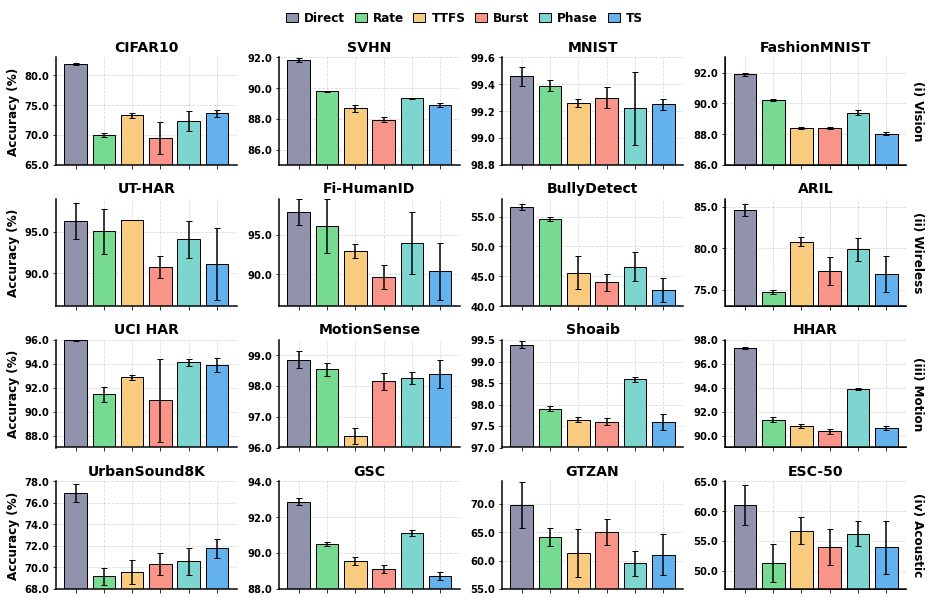

In [3]:
fig, axs = plt.subplots(4, 4, figsize=(13, 8))
categories = ['Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TS']
x = np.arange(len(categories))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic']
for i in range(4):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
        
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        # axs[i].set_yticks([])
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # 设置x label，只有最后一层显示
        axs[i][j].set_xticks(x)
        axs[i][j].set_xticklabels([])

axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)

axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)

axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)

axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)

colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']

# cifar10:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [81.83, 69.95, 73.33, 69.53, 72.35, 73.67]
errors = [0.17, 0.32, 0.40, 2.63, 1.66, 0.59]
axs[0][0].set_ylim(65, 83)
for i in x:
    axs[0][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i], label=categories[i],
        edgecolor='black', zorder=2)
    
# svhn:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [91.83, 89.78, 88.70, 87.95, 89.34, 88.89]
errors = [0.13, 0.04, 0.23, 0.17, 0.02, 0.11]
axs[0][1].set_ylim(85, 92)
for i in x:
    axs[0][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# mnist:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [99.46, 99.39, 99.26, 99.30, 99.22, 99.25]
errors = [0.07, 0.04, 0.03, 0.08, 0.27, 0.04]
axs[0][2].set_ylim(98.8, 99.6)
for i in x:
    axs[0][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# fashionmnist:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [91.90, 90.21, 88.42, 88.42, 89.40, 88.04]
errors = [0.11, 0.08, 0.08, 0.08, 0.18, 0.07]
axs[0][3].set_ylim(86, 93)
for i in x:
    axs[0][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# ut har:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [96.30, 95.06, 96.39, 90.73, 94.07, 91.12]
errors = [2.17, 2.72, 0., 1.38, 2.27, 4.36]
axs[1][0].set_ylim(86, 99)
for i in x:
    axs[1][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# fi-humanid:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [97.82, 96.07, 92.92, 89.67, 93.92, 90.40]
errors = [1.61, 3.42, 0.92, 1.53, 3.93, 3.57]
axs[1][1].set_ylim(86, 99.5)
for i in x:
    axs[1][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# bullydetect:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [56.65, 54.64, 45.64, 44.03, 46.59, 42.63]
errors = [0.47, 0.32, 2.79, 1.43, 2.41, 2.01]
axs[1][2].set_ylim(40, 58)
for i in x:
    axs[1][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# aril:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [84.65, 74.70, 80.82, 77.22, 79.86, 76.86]
errors = [0.75, 0.21, 0.55, 1.70, 1.44, 2.20]
axs[1][3].set_ylim(73, 86)
for i in x:
    axs[1][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# uci har:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'   
values = [96.02, 91.47, 92.87, 90.95, 94.15, 93.92]
errors = [0.09, 0.63, 0.18, 3.45, 0.3, 0.58]
axs[2][0].set_ylim(87, 96)
for i in x:
    axs[2][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

# motionsense:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [98.86, 98.54, 96.38, 98.16, 98.26, 98.39]
errors = [0.28, 0.22, 0.27, 0.28, 0.19, 0.45]
axs[2][1].set_ylim(96., 99.5)
for i in x:
    axs[2][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# shoaib:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [99.39, 97.90, 97.65, 97.60, 98.59, 97.59]
errors = [0.08, 0.06, 0.05, 0.08, 0.06, 0.18]
axs[2][2].set_ylim(97, 99.5)
for i in x:
    axs[2][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# hhar:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [97.32, 91.33, 90.82, 90.34, 93.87, 90.61]
errors = [0.07, 0.20, 0.16, 0.18, 0.09, 0.17]
axs[2][3].set_ylim(89, 98)
for i in x:
    axs[2][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)


# urbansound8k:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [76.95, 69.15, 69.59, 70.28, 70.54, 71.77]
errors = [0.84, 0.8, 1.13, 1.04, 1.27, 0.87]
axs[3][0].set_ylim(68, 78)
for i in x:
    axs[3][0].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# GSC:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [92.85, 90.51, 89.57, 89.10, 91.10, 88.72]
errors = [0.20, 0.11, 0.22, 0.22, 0.17, 0.21]
axs[3][1].set_ylim(88, 94)
for i in x:
    axs[3][1].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# GTZAN:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [69.83, 64.17, 61.33, 65, 59.50, 61]
errors = [4.01, 1.61, 4.31, 2.29, 2.18, 3.61]
axs[3][2].set_ylim(55, 74)
for i in x:
    axs[3][2].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# ESC:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [61, 51.33, 56.75, 54, 56.25, 53.92]
errors = [3.36, 3.22, 2.29, 3.04, 2.14, 4.50]
axs[3][3].set_ylim(47, 65)
for i in x:
    axs[3][3].bar(
        i, values[i],
        yerr=errors[i], capsize=3,
        color=colors[i],
        edgecolor='black', zorder=2)

fig.legend(
    categories, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=len(categories), 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=.8, 
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)
fig.tight_layout()
plt.savefig('./cmp-encoding-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

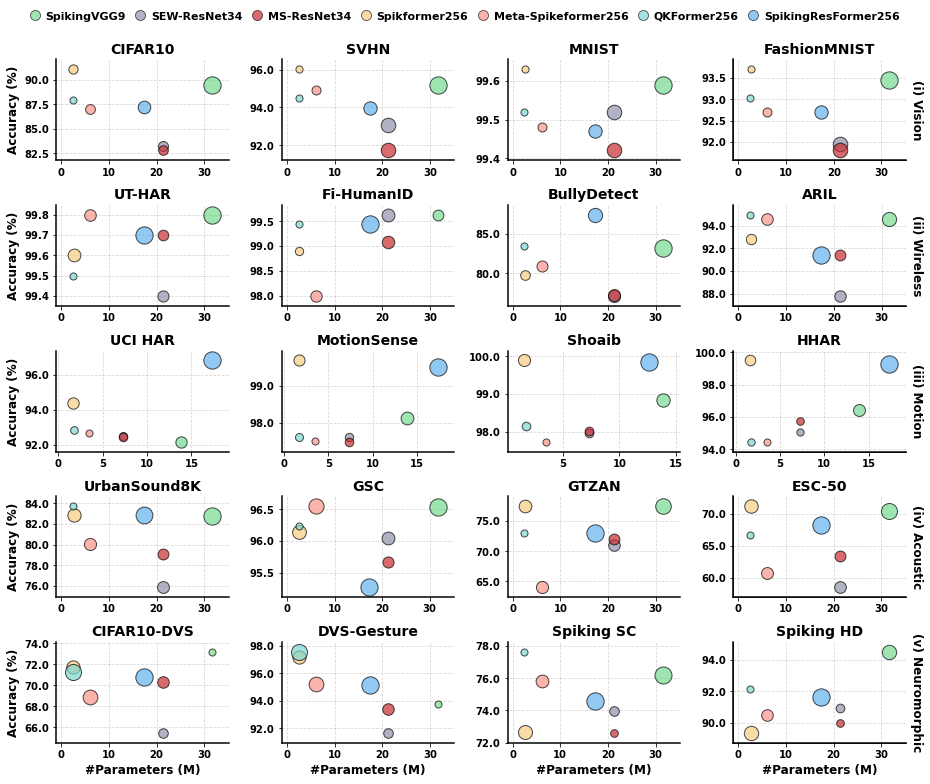

In [4]:
fig, axs = plt.subplots(5, 4, figsize=(13, 10.5))
colors = ['#76da91', '#9192ab', '#c82d31', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
for i in range(5):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        if i == 4:
            axs[i][j].set_xlabel('#Parameters (M)', fontweight='bold', fontsize=12)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
    
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


def adjust_ylim(ax, y, x=None, pad_ratio=0.12):
    y = np.array(y)
    y_min, y_max = y.min(), y.max()
    y_range = y_max - y_min
    ax.set_ylim(
        y_min - pad_ratio * y_range,
        y_max + pad_ratio * y_range
    )

    if x is not None:
        x = np.array(x)
        x_min, x_max = x.min(), x.max()
        x_range = x_max - x_min
        ax.set_xlim(
            x_min - pad_ratio * x_range,
            x_max + pad_ratio * x_range
        )

s_min, s_max = 50, 300

categories = ['SpikingVGG9', 'SEW-ResNet34','MS-ResNet34', 'Spikformer256', 
              'Meta-Spikeformer256', 'QKFormer256', 'SpikingResFormer256'] # vgg9, resnet34, former2
# cifar10
axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
accs = [89.53, 83.29, 82.79, 91.11, 87.07, 87.93, 87.22]
params = [31.61, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32]
costs = np.array([820.67, 198.23, 176, 153.31, 185.61, 42.31, 384.46])
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][0], accs, params)

# svhn
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
accs = [95.2, 93.08, 91.73, 96.02, 94.93, 94.51, 93.97]
params = np.array([31.61, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32])
costs = np.array([1661.38, 202.65, 177.08, 169.56, 182.88, 45.19, 383.36]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][1], accs, params)

# mnist
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
accs = [99.59, 99.52, 99.42, 99.63, 99.48, 99.52, 99.47]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([1273.11, 77.77, 69.04, 92.03, 89.69, 23.08, 264.03]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][2], accs, params)

# fashionmnist
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)
accs = [93.46, 91.95, 91.8, 93.71, 92.71, 93.04, 92.71]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([1192.67, 34.02, 30.25, 114.22, 94.22, 25.81, 199.25]) 
sizes = s_min + (params - params.min()) / (params.max() - params.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[0][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[0][3], accs, params)

# ut-har
axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
accs = [99.8, 99.4, 99.7, 99.6, 99.8, 99.5, 99.7]
params = [31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31]
costs = np.array([4790.23, 1717.97, 1513.71, 2396.2, 1899.94, 426.07, 4748.38]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][0], accs, params)

# fi-humanid
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
accs = [99.63, 99.63, 99.08, 98.9, 97.99, 99.45, 99.45]
params = [31.62, 21.29, 21.3, 2.57, 6.09, 2.42, 17.32]
costs = np.array([7392.13, 11482.72, 10700.59, 3282.74, 8416.59, 1675.69, 22965.19]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][1], accs, params)

# bullydetect
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
accs = [83.26, 77.1, 77.19, 79.82, 80.89, 83.44, 87.46]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.41, 17.32]
costs = np.array([6881.04, 3045.48, 2873.80, 1645.20, 2366.06, 533.35, 4427.03]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][2], accs, params)

# aril
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)
accs = [94.60, 87.77, 91.37, 92.81, 94.60, 94.96, 91.37]
params = [31.60, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31]
costs = np.array([1474.34, 868.95, 749.84, 672.84, 901.83, 180.52, 2307.88]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[1][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[1][3], accs, params)

# uci-har
axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
accs = [92.16, 92.47, 92.43, 94.37, 92.64, 92.81, 96.81]
params = [13.87, 7.28, 7.28, 1.63, 3.51, 1.74, 17.31]
costs = np.array([29.79, 10.59, 12.67, 30.31, 5.51, 8.18, 83.15]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][0], accs, params)

# motionsense
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
accs = [98.12, 97.6, 97.48, 99.7, 97.51, 97.6, 99.52]
params = [13.87, 7.28, 7.28, 1.64, 3.51, 1.74, 17.31]
costs = np.array([50.23, 15.11, 16.4, 35.43, 7.72, 13.08, 101.6]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][1], accs, params)

# shoaib
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
accs = [98.84, 97.95, 98.02, 99.89, 97.73, 98.16, 99.86]
params = [13.87, 7.28, 7.28, 1.62, 3.51, 1.74, 12.56]
costs = np.array([51.65, 15.77, 16.55, 40.49, 7.39, 15.73, 93.65]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][2], accs, params)

# hhar
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)
accs = [96.4, 95.05, 95.75, 99.49, 94.47, 94.48, 99.26]
params = [13.87, 7.28, 7.28, 1.62, 3.51, 1.74, 17.31]
costs = np.array([39.55, 3.41, 5.8, 27.32, 2.36, 3.96, 102.73]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[2][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[2][3], accs, params)

# urbansound8k
axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
accs = [82.76, 75.86, 79.07, 82.88, 80.04, 83.73, 82.88]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([3425.88, 1458.24, 1185.28, 1885.05, 1544.79, 328.97, 3219.93]) / 1000 # mj
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][0], accs, params)

# gsc
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
accs = [96.53, 96.04, 95.67, 96.14, 96.55, 96.23, 95.27]
params = np.array([31.66, 21.3, 21.3, 2.57, 6.09, 2.41, 17.32])
costs = np.array([2824.65, 1573.78, 1189.65, 1808.95, 2195.36, 511, 2789.32]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][1], accs, params)

# gtzan
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
accs = [77.5, 71, 72, 77.5, 64, 73, 73]
params = np.array([31.61, 21.28, 21.29, 2.57, 6.08, 2.41, 17.31])
costs = np.array([2908.94, 1431.12, 1214.06, 1784.31, 1632.79, 311.82, 3672.51]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][2], accs, params)

# esc-50
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)
accs = [70.5, 58.5, 63.5, 71.25, 60.75, 66.75, 68.25]
params = [31.69, 21.3, 21.31, 2.58, 6.09, 2.43, 17.33]
costs = np.array([2931.87, 1433.94, 1196.17, 1981.97, 1485.05, 324.71, 3471.66]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[3][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[3][3], accs, params)


# cifar10-dvs
axs[4][0].set_title('CIFAR10-DVS', fontweight='bold', fontsize=14)
accs = [73.2, 65.45, 70.35, 71.7, 68.85, 71.3, 70.8]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.42, 17.32]
costs = np.array([1, 2, 3, 4, 5, 6, 7]) # TODO 后面再改成param是size，x轴是costs
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][0].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][0], accs, params)

# dvs-gesture
axs[4][1].set_title('DVS-Gesture', fontweight='bold', fontsize=14)
accs = [93.75, 91.67, 93.4, 97.22, 95.24, 97.57, 95.14]
params = [31.61, 21.29, 21.29, 2.57, 6.08, 2.42, 17.32]
costs = np.array([1, 2, 3, 4, 5, 6, 7]) # TODO 后面再改成param是size，x轴是costs
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][1].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][1], accs, params)

# ssc
axs[4][2].set_title('Spiking SC', fontweight='bold', fontsize=14)
accs = [76.22, 73.96, 72.6, 72.69, 75.83, 77.64, 74.61]
params = [31.66, 21.3, 21.3, 2.57, 6.09, 2.42, 17.32]
costs = np.array([5160.73, 1419.89, 775.27, 3382.03, 2731.23, 589.53, 5357.59]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][2].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][2], accs, params)

# shd   
axs[4][3].set_title('Spiking HD', fontweight='bold', fontsize=14)
accs = [94.52, 90.95, 89.97, 89.36, 90.5, 92.14, 91.65]
params = [31.63, 21.29, 21.29, 2.57, 6.09, 2.42, 17.32]
costs = np.array([4796.67, 1314.91, 847.97, 4804.35, 2903.08, 603.97, 7333.23]) 
sizes = s_min + (costs - costs.min()) / (costs.max() - costs.min() + 1e-8) * (s_max - s_min)
for idx in range(len(categories)):
    axs[4][3].scatter(
        params[idx], accs[idx], label=categories[idx], 
        color=colors[idx], s=sizes[idx], edgecolors='black', alpha=0.7, zorder=3)
adjust_ylim(axs[4][3], accs, params)


legend_size = 70
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=colors[i],
        markeredgecolor='black',
        markeredgewidth=0.8,
        alpha=0.7,
        markersize=np.sqrt(legend_size),  # 注意：markersize 是“半径”
        label=categories[i]
    )
    for i in range(len(categories))
]
fig.legend(
    handles=legend_handles,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.04), 
    ncol=7, 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=.8, 
    markerscale=1.2,
    prop={'weight': 'bold', 'size': 11},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-topology-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

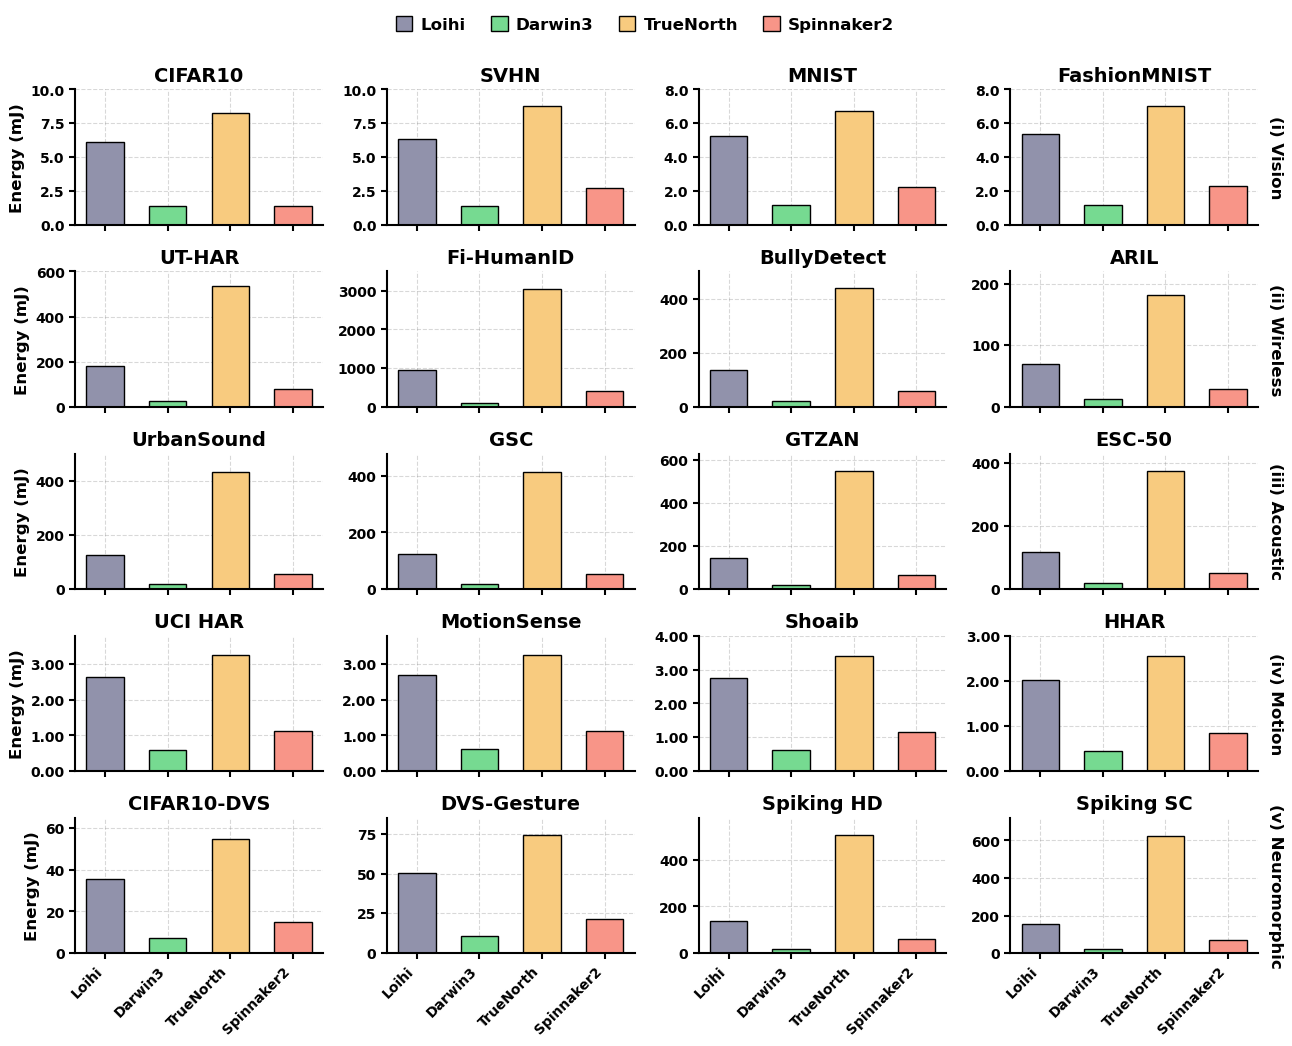

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter

fig, axs = plt.subplots(5, 4, figsize=(13, 10))

devices = ['Loihi', 'Darwin3', 'TrueNorth', 'Spinnaker2']
x = np.arange(len(devices))
colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588']
modalities = ['(i) Vision', '(ii) Wireless', '(iii) Acoustic', '(iv) Motion', '(v) Neuromorphic']

BAR_WIDTH = 0.6 

for row in range(5):
    for col in range(4):
        ax = axs[row][col]
        
        if col == 0:
            ax.set_ylabel('Energy (mJ)', fontweight='bold', fontsize=12, color='black')

        if col == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[row]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.tick_params(axis='x', which='both', bottom=True, top=False, 
                       colors='black', width=1.5, length=4, direction='out')
        ax.tick_params(axis='y', which='both', left=True, right=False, 
                       colors='black', width=1.5, length=4, direction='out')
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        if row == 3: 
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        elif row in [1, 2, 4]: 
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
        else:
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        ax.set_xticks(x)
        if row == 4: 
            ax.set_xticklabels(devices, fontsize=10, fontweight='bold', color='black', 
                               rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],               
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],            
    ['UrbanSound', 'GSC', 'GTZAN', 'ESC-50'],                   
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],               
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking HD', 'Spiking SC']  
]

for r in range(5):
    for c in range(4):
        axs[r][c].set_title(titles[r][c], fontweight='bold', fontsize=14, color='black')

def plot_bar(ax, values):
    for k in x:
        ax.bar(
            k, values[k],
            width=BAR_WIDTH, 
            color=colors[k],
            edgecolor='black', 
            linewidth=1.0, 
            zorder=2
        )

# Vision
values = [6.1437, 1.3738, 8.27, 1.3738]
axs[0][0].set_ylim(0, 10)
plot_bar(axs[0][0], values)

values = [6.3147, 1.4067, 8.7677, 2.6758]
axs[0][1].set_ylim(0, 10)
plot_bar(axs[0][1], values)

values = [5.2618, 1.1638, 6.7371, 2.2296]
axs[0][2].set_ylim(0, 8)
plot_bar(axs[0][2], values)

values = [5.3863, 1.1868, 7.0405, 2.2823]
axs[0][3].set_ylim(0, 8)
plot_bar(axs[0][3], values)

# Wireless
values = [180.0229, 26.8994, 533.5221, 76.852]
axs[1][0].set_ylim(0, 600)
plot_bar(axs[1][0], values)

values = [940.8663, 92.0029, 3040.3329, 413.5679]
axs[1][1].set_ylim(0, 3500)
plot_bar(axs[1][1], values)

values = [135.6374, 21.0083, 437.5203, 58.2449]
axs[1][2].set_ylim(0, 500)
plot_bar(axs[1][2], values)

values = [70.0194, 12.0706, 182.4128, 29.5083]
axs[1][3].set_ylim(0, 220)
plot_bar(axs[1][3], values)

# Acoustic
values = [125.8839, 19.0423, 430.2877, 54.3214]
axs[2][0].set_ylim(0, 500)
plot_bar(axs[2][0], values)

values = [123.8498, 18.9577, 413.3128, 53.2872]
axs[2][1].set_ylim(0, 480)
plot_bar(axs[2][1], values)

values = [145.1369, 20.1845, 547.0841, 62.6666]
axs[2][2].set_ylim(0, 630)
plot_bar(axs[2][2], values)

values = [117.5003, 18.5628, 374.8386, 50.8244]
axs[2][3].set_ylim(0, 430)
plot_bar(axs[2][3], values)

# Motion
values = [2.6331, 0.5953, 3.2527, 1.1157]
axs[3][0].set_ylim(0, 3.8)
plot_bar(axs[3][0], values)

values = [2.6834, 0.6087, 3.2598, 1.137]
axs[3][1].set_ylim(0, 3.8)
plot_bar(axs[3][1], values)

values = [2.7417, 0.6205, 3.3851, 1.1617]
axs[3][2].set_ylim(0, 4.0)
plot_bar(axs[3][2], values)

values = [2.0133, 0.4533, 2.5457, 0.8514]
axs[3][3].set_ylim(0, 3.0)
plot_bar(axs[3][3], values)

# Neuromorphic
values = [35.3693, 7.469, 54.9007, 14.7843]
axs[4][0].set_ylim(0, 65)
plot_bar(axs[4][0], values)

values = [50.6123, 10.7699, 73.9036, 21.3573]
axs[4][1].set_ylim(0, 85)
plot_bar(axs[4][1], values)

values = [137.1459, 19.4016, 504.7549, 59.3721]
axs[4][2].set_ylim(0, 580)
plot_bar(axs[4][2], values)

values = [156.6937, 20.5925, 621.0846, 67.5835]
axs[4][3].set_ylim(0, 720)
plot_bar(axs[4][3], values)

legend_patches = []
for c, l in zip(colors, devices):
    patch = mpatches.Patch(
        facecolor=c, 
        edgecolor='black', 
        linewidth=1.0, 
        label=l
    )
    legend_patches.append(patch)

fig.legend(
    handles=legend_patches,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=len(devices), 
    handlelength=1,     
    handleheight=1,     
    handletextpad=0.5, 
    columnspacing=1.5, 
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-energy-sensing-device.pdf', dpi=300, bbox_inches="tight")
plt.show()

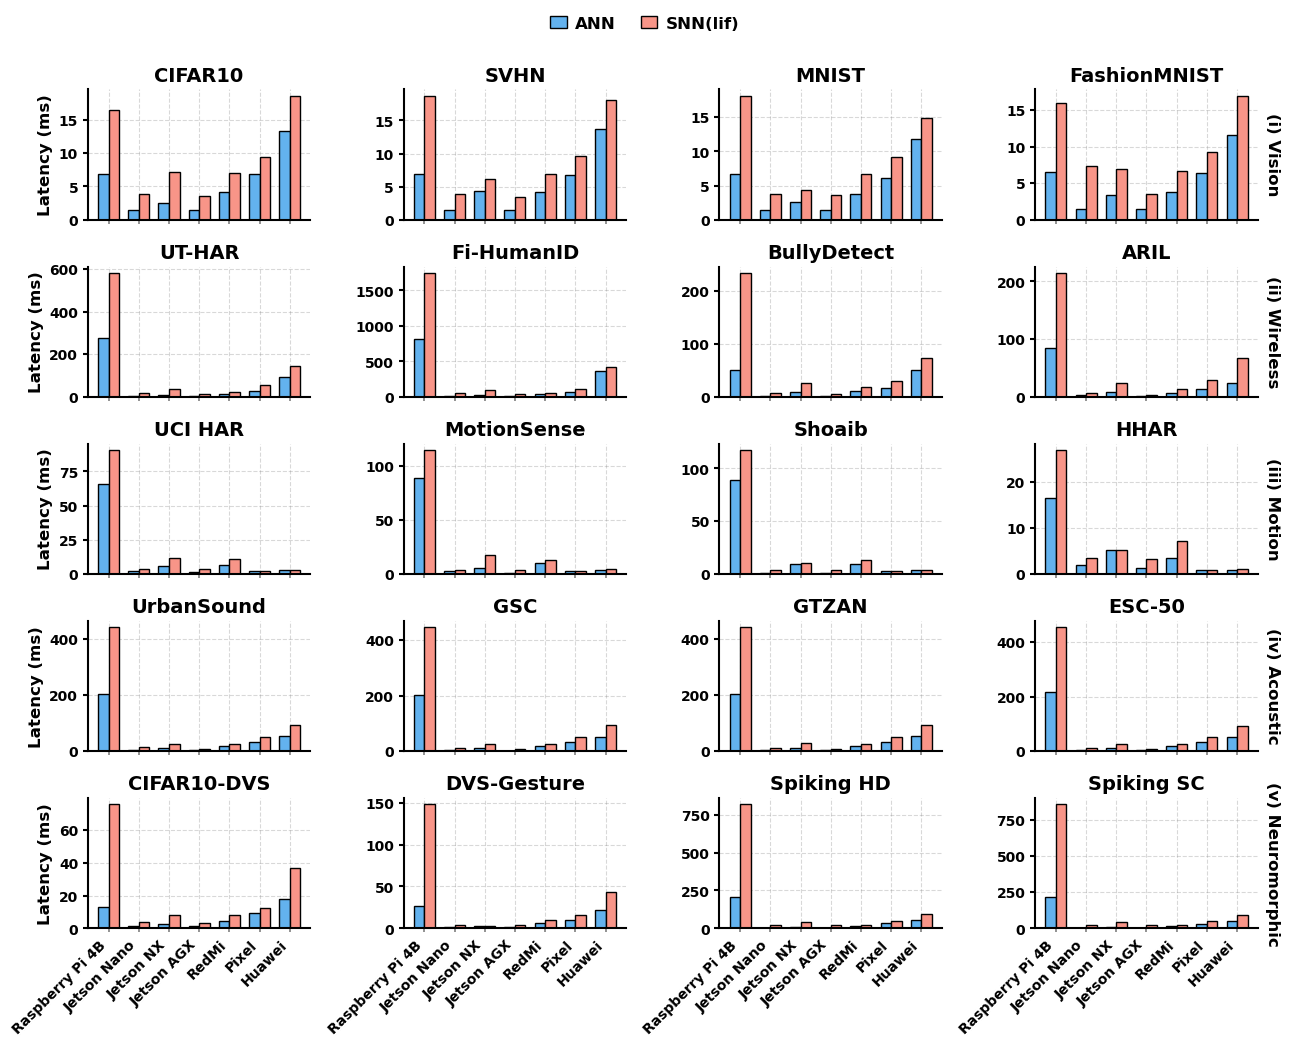

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

devices = ['Raspberry Pi 4B', 'Jetson Nano', 'Jetson NX', 'Jetson AGX', 'RedMi', 'Pixel', 'Huawei']
x = np.arange(len(devices))

data = {
    "Vision": {
        "CIFAR10": {"ann": [6.809, 1.441, 2.456, 1.384, 4.137, 6.895, 13.373], "snn": [16.516, 3.929, 7.138, 3.563, 6.968, 9.430, 18.686]},
        "SVHN": {"ann": [6.837, 1.446, 4.321, 1.396, 4.130, 6.736, 13.691], "snn": [18.774, 3.939, 6.11, 3.475, 6.950, 9.601, 18.146]},
        "MNIST": {"ann": [6.672, 1.48, 2.596, 1.392, 3.768, 6.148, 11.801], "snn": [18.193, 3.707, 4.325, 3.616, 6.748, 9.147, 14.856]},
        "FashionMNIST": {"ann": [6.547, 1.409, 3.372, 1.409, 3.763, 6.370, 11.545], "snn": [15.945, 7.39, 6.9, 3.558, 6.723, 9.327, 16.998]}
    },
    "Wireless": {
        "UT-HAR": {"ann": [276.546, 3.043, 10.933, 2.468, 11.996, 27.807, 91.280], "snn": [582.708, 17.698, 37.74, 12.217, 22.312, 56.381, 144.796]},
        "Fi-HumanID": {"ann": [820.848, 10.497, 21.544, 6.805, 45.500, 75.207, 360.103], "snn": [1749.858, 52.495, 99.821, 39.899, 58.812, 104.643, 427.715]},
        "BullyDetect": {"ann": [50.137, 2.488, 9.392, 1.446, 11.809, 17.158, 50.747], "snn": [234.911, 7.13, 25.909, 6.241, 19.456, 29.501, 74.157]},
        "ARIL": {"ann": [85.174, 2.637, 9.124, 1.739, 6.688, 14.172, 24.510], "snn": [215.049, 6.14, 24.814, 4.038, 13.726, 28.733, 66.945]}
    },
    "Motion": {
        "UCI HAR": {"ann": [65.982, 2.211, 5.798, 1.377, 6.826, 2.382, 2.670], "snn": [90.65, 3.829, 11.876, 3.385, 10.721, 2.421, 3.225]},
        "MotionSense": {"ann": [88.777, 2.735, 5.895, 1.384, 9.980, 3.021, 3.435], "snn": [114.469, 3.691, 17.523, 3.569, 12.998, 3.218, 4.447]},
        "Shoaib": {"ann": [88.951, 1.45, 9.544, 1.356, 9.964, 3.061, 3.528], "snn": [117.567, 3.762, 10.033, 3.413, 13.058, 3.169, 4.273]},
        "HHAR": {"ann": [16.512, 1.951, 5.268, 1.36, 3.408, 0.791, 0.803], "snn": [26.884, 3.561, 5.299, 3.35, 7.098, 0.823, 1.097]}
    },
    "Acoustic": {
        "UrbanSound": {"ann": [202.943, 2.742, 10.041, 2.851, 18.458, 33.467, 53.355], "snn": [441.249, 16.652, 25.793, 8.906, 27.213, 50.266, 92.101]},
        "GSC": {"ann": [200.71, 5.299, 9.965, 1.898, 18.396, 33.631, 52.913], "snn": [446.305, 10.712, 26.672, 8.91, 27.102, 50.267, 93.409]},
        "GTZAN": {"ann": [202.025, 5.535, 11.834, 3.064, 18.470, 33.485, 52.911], "snn": [440.765, 10.726, 28.996, 8.916, 27.362, 50.451, 92.044]},
        "ESC-50": {"ann": [217.735, 5.495, 10.505, 2.854, 18.241, 33.598, 53.618], "snn": [453.891, 10.74, 25.943, 8.94, 26.945, 50.317, 92.857]}
    },
    "Neuromorphic": {
        "CIFAR10-DVS": {"ann": [12.821, 1.408, 2.481, 1.424, 4.757, 9.176, 18.085], "snn": [75.823, 3.809, 8.447, 3.53, 8.321, 12.316, 36.738]},
        "DVS-Gesture": {"ann": [26.973, 1.755, 2.315, 1.422, 5.900, 10.289, 21.903], "snn": [147.987, 4.318, 2.315, 3.83, 9.552, 16.219, 42.918]},
        "Spiking HD": {"ann": [210.121, 5.274, 9.901, 4.289, 18.456, 33.527, 53.443], "snn": [817.99, 20.542, 44.702, 20.507, 24.369, 50.509, 92.923]},
        "Spiking SC": {"ann": [218.134, 4.782, 9.964, 4.284, 18.476, 33.357, 53.331], "snn": [855.917, 20.549, 44.768, 20.514, 24.310, 50.999, 93.645]}
    }
}

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']

modality_labels = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']
c_ann = colors[5]  
c_snn = colors[3]  

fig, axs = plt.subplots(5, 4, figsize=(13, 10)) 
width = 0.35

for i, modality in enumerate(modalities):
    datasets = list(data[modality].keys())
    
    for j in range(4):
        ax = axs[i][j]
        
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('black')
        
        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        for label in ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        if j == 0:
            ax.set_ylabel('Latency (ms)', fontweight='bold', fontsize=12, color='black')

        if j == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modality_labels[i]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f')) 
        ax.tick_params(axis='y', colors='black', width=1.5)

        ax.set_xticks(x)

        ax.tick_params(
            axis='x', 
            colors='gray',    
            width=1.2,        
            length=3,         
            direction='out',
            top=False, 
            bottom=True
        )

        if i == 4: 
            ax.set_xticklabels(devices, fontsize=10, fontweight='bold', color='black', 
                               rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

        if j < len(datasets):
            d_name = datasets[j]
            ax.set_title(d_name, fontweight='bold', fontsize=14, color='black')
            
            ann_vals = data[modality][d_name]['ann']
            snn_vals = data[modality][d_name]['snn']
            
            ax.bar(x - width/2, ann_vals, width, label='ANN', color=c_ann, edgecolor='black', zorder=2)
            ax.bar(x + width/2, snn_vals, width, label='SNN(lif)', color=c_snn, edgecolor='black', zorder=2)
        else:
            ax.axis('off')

fig.legend(
    ['ANN', 'SNN(lif)'], 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=2, 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=1.5,
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-latency-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

/var/folders/_b/9c6z80pd7b744tf5ym_k8q0c0000gn/T/ipykernel_5087/743760731.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


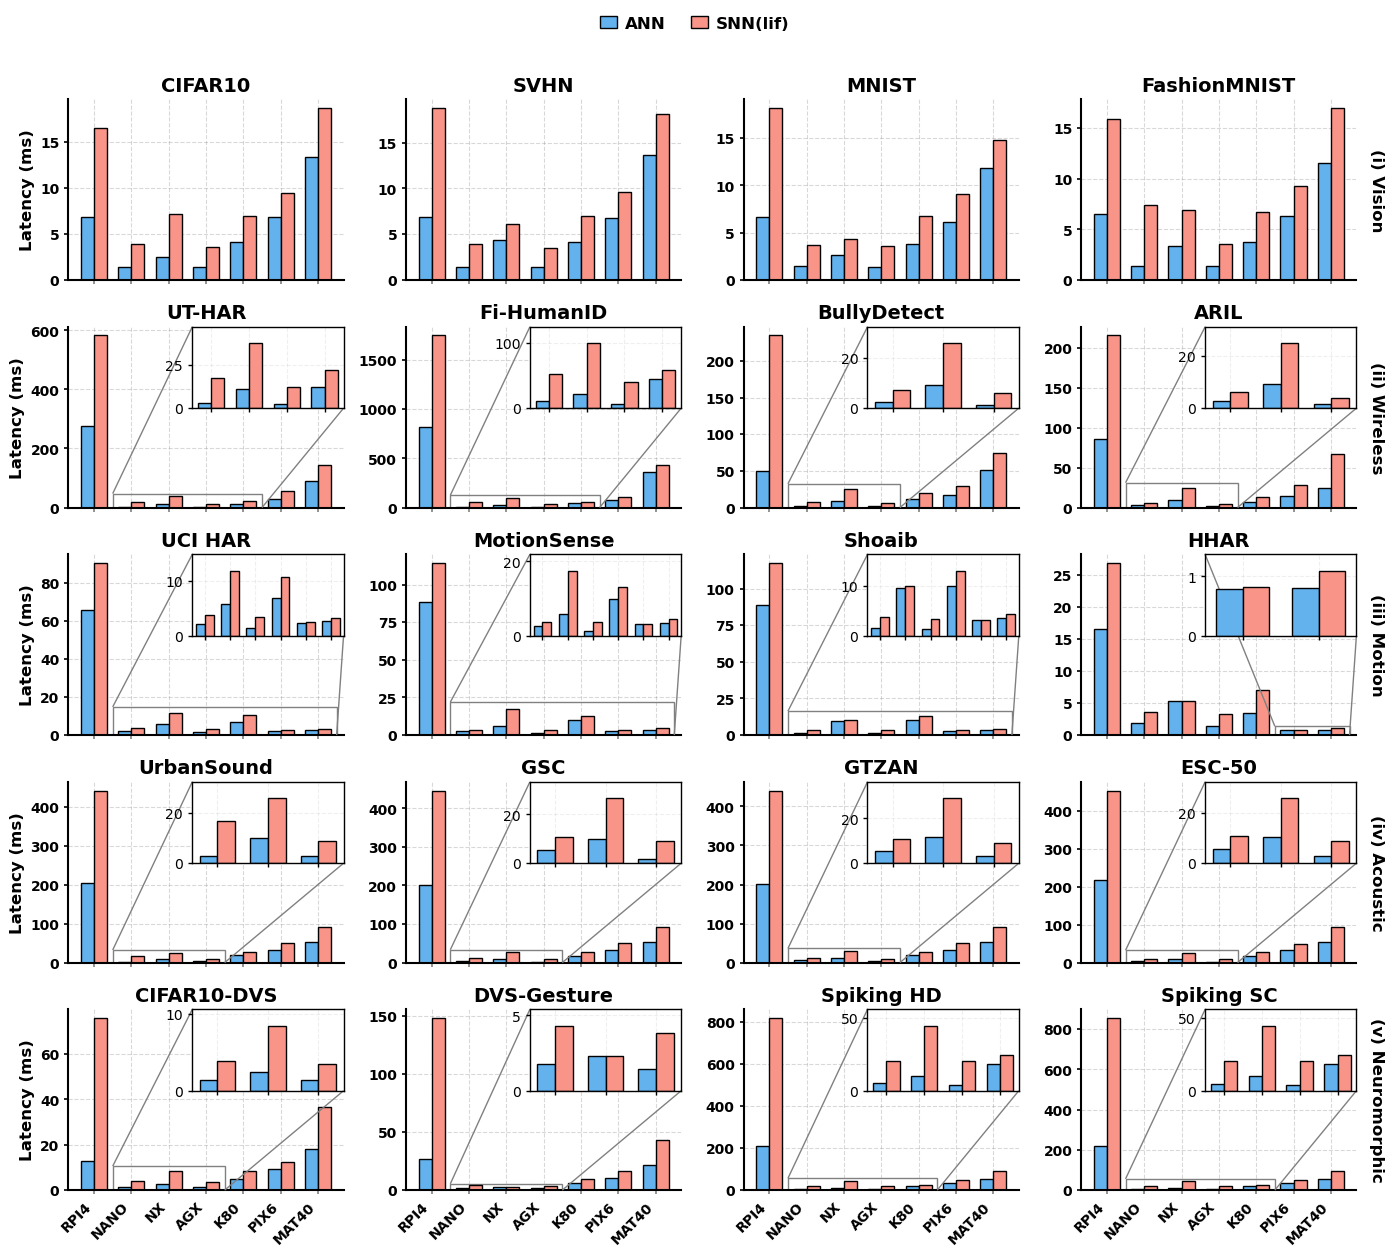

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

devices_short = ['RPI4', 'NANO', 'NX', 'AGX', 'K80', 'PIX6', 'MAT40']
x = np.arange(len(devices_short))

data = {
    "Vision": {
        "CIFAR10": {"ann": [6.809, 1.441, 2.456, 1.384, 4.137, 6.895, 13.373], "snn": [16.516, 3.929, 7.138, 3.563, 6.968, 9.430, 18.686]},
        "SVHN": {"ann": [6.837, 1.446, 4.321, 1.396, 4.130, 6.736, 13.691], "snn": [18.774, 3.939, 6.11, 3.475, 6.950, 9.601, 18.146]},
        "MNIST": {"ann": [6.672, 1.48, 2.596, 1.392, 3.768, 6.148, 11.801], "snn": [18.193, 3.707, 4.325, 3.616, 6.748, 9.147, 14.856]},
        "FashionMNIST": {"ann": [6.547, 1.409, 3.372, 1.409, 3.763, 6.370, 11.545], "snn": [15.945, 7.39, 6.9, 3.558, 6.723, 9.327, 16.998]}
    },
    "Wireless": {
        "UT-HAR": {"ann": [276.546, 3.043, 10.933, 2.468, 11.996, 27.807, 91.280], "snn": [582.708, 17.698, 37.74, 12.217, 22.312, 56.381, 144.796]},
        "Fi-HumanID": {"ann": [820.848, 10.497, 21.544, 6.805, 45.500, 75.207, 360.103], "snn": [1749.858, 52.495, 99.821, 39.899, 58.812, 104.643, 427.715]},
        "BullyDetect": {"ann": [50.137, 2.488, 9.392, 1.446, 11.809, 17.158, 50.747], "snn": [234.911, 7.13, 25.909, 6.241, 19.456, 29.501, 74.157]},
        "ARIL": {"ann": [85.174, 2.637, 9.124, 1.739, 6.688, 14.172, 24.510], "snn": [215.049, 6.14, 24.814, 4.038, 13.726, 28.733, 66.945]}
    },
    "Motion": {
        "UCI HAR": {"ann": [65.982, 2.211, 5.798, 1.377, 6.826, 2.382, 2.670], "snn": [90.65, 3.829, 11.876, 3.385, 10.721, 2.421, 3.225]},
        "MotionSense": {"ann": [88.777, 2.735, 5.895, 1.384, 9.980, 3.021, 3.435], "snn": [114.469, 3.691, 17.523, 3.569, 12.998, 3.218, 4.447]},
        "Shoaib": {"ann": [88.951, 1.45, 9.544, 1.356, 9.964, 3.061, 3.528], "snn": [117.567, 3.762, 10.033, 3.413, 13.058, 3.169, 4.273]},
        "HHAR": {"ann": [16.512, 1.951, 5.268, 1.36, 3.408, 0.791, 0.803], "snn": [26.884, 3.561, 5.299, 3.35, 7.098, 0.823, 1.097]}
    },
    "Acoustic": {
        "UrbanSound": {"ann": [202.943, 2.742, 10.041, 2.851, 18.458, 33.467, 53.355], "snn": [441.249, 16.652, 25.793, 8.906, 27.213, 50.266, 92.101]},
        "GSC": {"ann": [200.71, 5.299, 9.965, 1.898, 18.396, 33.631, 52.913], "snn": [446.305, 10.712, 26.672, 8.91, 27.102, 50.267, 93.409]},
        "GTZAN": {"ann": [202.025, 5.535, 11.834, 3.064, 18.470, 33.485, 52.911], "snn": [440.765, 10.726, 28.996, 8.916, 27.362, 50.451, 92.044]},
        "ESC-50": {"ann": [217.735, 5.495, 10.505, 2.854, 18.241, 33.598, 53.618], "snn": [453.891, 10.74, 25.943, 8.94, 26.945, 50.317, 92.857]}
    },
    "Neuromorphic": {
        "CIFAR10-DVS": {"ann": [12.821, 1.408, 2.481, 1.424, 4.757, 9.176, 18.085], "snn": [75.823, 3.809, 8.447, 3.53, 8.321, 12.316, 36.738]},
        "DVS-Gesture": {"ann": [26.973, 1.755, 2.315, 1.422, 5.900, 10.289, 21.903], "snn": [147.987, 4.318, 2.315, 3.83, 9.552, 16.219, 42.918]},
        "Spiking HD": {"ann": [210.121, 5.274, 9.901, 4.289, 18.456, 33.527, 53.443], "snn": [817.99, 20.542, 44.702, 20.507, 24.369, 50.509, 92.923]},
        "Spiking SC": {"ann": [218.134, 4.782, 9.964, 4.284, 18.476, 33.357, 53.331], "snn": [855.917, 20.549, 44.768, 20.514, 24.310, 50.999, 93.645]}
    }
}

modalities = ['Vision', 'Wireless', 'Motion', 'Acoustic', 'Neuromorphic']
modality_labels = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

inset_config = {
    (0,0): None, (0,1): None, (0,2): None, (0,3): None,
    (1,0): [1, 2, 3, 4], (1,1): [1, 2, 3, 4], (1,2): [1, 2, 3], (1,3): [1, 2, 3],
    (2,0): [1, 2, 3, 4, 5, 6], (2,1): [1, 2, 3, 4, 5, 6], (2,2): [1, 2, 3, 4, 5, 6], (2,3): [5, 6],
    (3,0): [1, 2, 3], (3,1): [1, 2, 3], (3,2): [1, 2, 3], (3,3): [1, 2, 3],
    (4,0): [1, 2, 3], (4,1): [1, 2, 3], (4,2): [1, 2, 3, 4], (4,3): [1, 2, 3, 4]
}

fig, axs = plt.subplots(5, 4, figsize=(14, 12))
width = 0.35

for i, modality in enumerate(modalities):
    datasets = list(data[modality].keys())

    for j in range(4):
        ax = axs[i][j]

        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('black')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)

        for label in ax.get_yticklabels():
            label.set_fontsize(10)
            label.set_fontweight('bold')
            label.set_color('black')

        if j == 0:
            ax.set_ylabel('Latency (ms)', fontweight='bold', fontsize=12, color='black')

        if j == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(modality_labels[i], fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
        ax.tick_params(
            axis='y', colors='black', width=1.2, length=3, direction='out',
            left=True, right=False
        )

        ax.set_xticks(x)
        ax.tick_params(
            axis='x', colors='gray', width=1.2, length=3, direction='out',
            top=False, bottom=True
        )

        if i == 4:
            ax.set_xticklabels(devices_short, fontsize=10, fontweight='bold', color='black',
                               rotation=45, ha='right')
        else:
            ax.set_xticklabels([])

        if j < len(datasets):
            d_name = datasets[j]
            ax.set_title(d_name, fontweight='bold', fontsize=14, color='black')

            ann_vals = data[modality][d_name]['ann']
            snn_vals = data[modality][d_name]['snn']

            ax.bar(x - width/2, ann_vals, width, label='ANN', color=colors[5], edgecolor='black', zorder=2)
            ax.bar(x + width/2, snn_vals, width, label='SNN(lif)', color=colors[3], edgecolor='black', zorder=2)

            indices_to_show = inset_config.get((i, j))
            if indices_to_show:
                zoom_indices = np.array(indices_to_show)
                zoom_ann = np.array(ann_vals)[zoom_indices]
                zoom_snn = np.array(snn_vals)[zoom_indices]
                zoom_x = x[zoom_indices]

                zoom_max = max(zoom_ann.max(), zoom_snn.max())

                axins = inset_axes(
                    ax, width="55%", height="45%", loc='upper right', borderpad=0
                )

                axins.bar(zoom_x - width/2, zoom_ann, width, color=colors[5], edgecolor='black', zorder=2)
                axins.bar(zoom_x + width/2, zoom_snn, width, color=colors[3], edgecolor='black', zorder=2)

                axins.set_xlim(zoom_indices.min() - 0.5, zoom_indices.max() + 0.5)
                axins.set_ylim(0, zoom_max * 1.25)

                # ---- inset ticks: show tick marks but hide labels ----
                axins.set_xticks(zoom_x)
                axins.tick_params(
                    axis='x', which='major',
                    bottom=True, top=False,
                    labelbottom=False,
                    colors='black',
                    width=1.0, length=3, direction='out'
                )
                axins.tick_params(
                    axis='y', which='major',
                    left=True, right=False,
                    labelleft=True,
                    colors='black',
                    width=1.0, length=3, direction='out'
                )

                axins.set_facecolor('white')
                axins.grid(True, linestyle='--', alpha=0.2)

                for spine in axins.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_linewidth(1)

                mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="grey", lw=1.0, linestyle='-')
        else:
            ax.axis('off')

fig.legend(
    ['ANN', 'SNN(lif)'],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    handlelength=1,
    handletextpad=0.5,
    columnspacing=1.5,
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-latency-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

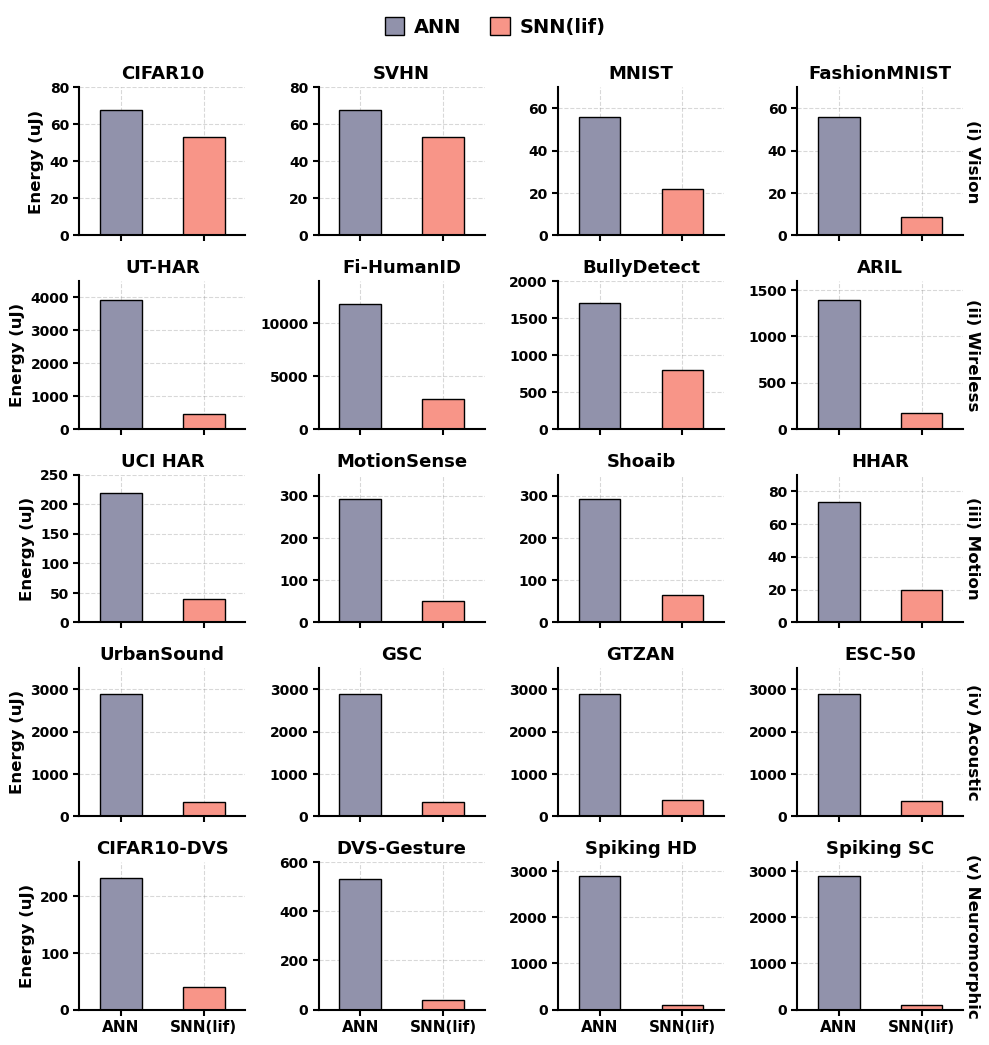

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter

fig, axs = plt.subplots(5, 4, figsize=(10, 10))

categories = ['ANN', 'SNN(lif)']
x = np.arange(len(categories))

colors = ['#9192ab', '#f89588'] 

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

BAR_WIDTH = 0.5 

for row in range(5):
    for col in range(4):
        ax = axs[row][col]
        
        if col == 0:
            ax.set_ylabel('Energy (uJ)', fontweight='bold', fontsize=12, color='black')

        if col == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[row]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.tick_params(axis='x', which='both', bottom=True, top=False, 
                       colors='black', width=1.5, length=4, direction='out')
        ax.tick_params(axis='y', which='both', left=True, right=False, 
                       colors='black', width=1.5, length=4, direction='out')
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

        ax.set_xticks([0, 1]) 
        ax.set_xlim(-0.5, 1.5) 

        if row == 4: 
            ax.set_xticklabels(categories, fontsize=11, fontweight='bold', color='black', 
                               rotation=0)
        else:
            ax.set_xticklabels([])

titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],               
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],            
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],               
    ['UrbanSound', 'GSC', 'GTZAN', 'ESC-50'],                   
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking HD', 'Spiking SC']  
]

for r in range(5):
    for c in range(4):
        axs[r][c].set_title(titles[r][c], fontweight='bold', fontsize=13, color='black')

def plot_pair(ax, ann_val, snn_val):
    ax.bar(0, ann_val, width=BAR_WIDTH, color=colors[0], edgecolor='black', linewidth=1.0, zorder=2)
    ax.bar(1, snn_val, width=BAR_WIDTH, color=colors[1], edgecolor='black', linewidth=1.0, zorder=2)

# Row 0: Vision
# CIFAR10
axs[0][0].set_ylim(0, 80)
plot_pair(axs[0][0], 67.49, 52.9)
# SVHN
axs[0][1].set_ylim(0, 80)
plot_pair(axs[0][1], 67.49, 52.94)
# MNIST
axs[0][2].set_ylim(0, 70)
plot_pair(axs[0][2], 55.95, 21.93)
# FashionMNIST
axs[0][3].set_ylim(0, 70)
plot_pair(axs[0][3], 55.95, 8.74)

# Row 1: Wireless
# UT-HAR
axs[1][0].set_ylim(0, 4500)
plot_pair(axs[1][0], 3919.48, 452)
# Fi-HumanID
axs[1][1].set_ylim(0, 14000)
plot_pair(axs[1][1], 11790.94, 2853.14)
# BullyDetect
axs[1][2].set_ylim(0, 2000)
plot_pair(axs[1][2], 1698.64, 791.23)
# ARIL
axs[1][3].set_ylim(0, 1600)
plot_pair(axs[1][3], 1388.92, 174.85)

# Row 2: Motio===
# UCI HAR
axs[2][0].set_ylim(0, 250)
plot_pair(axs[2][0], 219.52, 39.48)
# MotionSense
axs[2][1].set_ylim(0, 350)
plot_pair(axs[2][1], 292.69, 49.76)
# Shoaib
axs[2][2].set_ylim(0, 350)
plot_pair(axs[2][2], 292.69, 64.14)
# HHAR
axs[2][3].set_ylim(0, 90)
plot_pair(axs[2][3], 73.19, 19.98)

# Row 3: Acoustic===
# UrbanSound
axs[3][0].set_ylim(0, 3500)
plot_pair(axs[3][0], 2891.85, 322.84)
# GSC
axs[3][1].set_ylim(0, 3500)
plot_pair(axs[3][1], 2891.97, 321.21)
# GTZAN
axs[3][2].set_ylim(0, 3500)
plot_pair(axs[3][2], 2891.85, 383.19)
# ESC-50
axs[3][3].set_ylim(0, 3500)
plot_pair(axs[3][3], 2892.04, 363.67)

# Row 4: Neuromorphic
# CIFAR10-DVS
axs[4][0].set_ylim(0, 260)
plot_pair(axs[4][0], 230.93, 40.14)
# DVS-Gesture
axs[4][1].set_ylim(0, 600)
plot_pair(axs[4][1], 528.68, 40.39)
# Spiking HD
axs[4][2].set_ylim(0, 3200)
plot_pair(axs[4][2], 2891.9, 97.76)
# Spiking SC
axs[4][3].set_ylim(0, 3200)
plot_pair(axs[4][3], 2891.97, 104.04)

legend_patches = [
    mpatches.Patch(facecolor=colors[0], edgecolor='black', linewidth=1.0, label='ANN'),
    mpatches.Patch(facecolor=colors[1], edgecolor='black', linewidth=1.0, label='SNN(lif)')
]

fig.legend(
    handles=legend_patches,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=2, 
    handlelength=1,     
    handleheight=1,     
    handletextpad=0.5, 
    columnspacing=1.5, 
    prop={'weight': 'bold', 'size': 14},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-energy-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

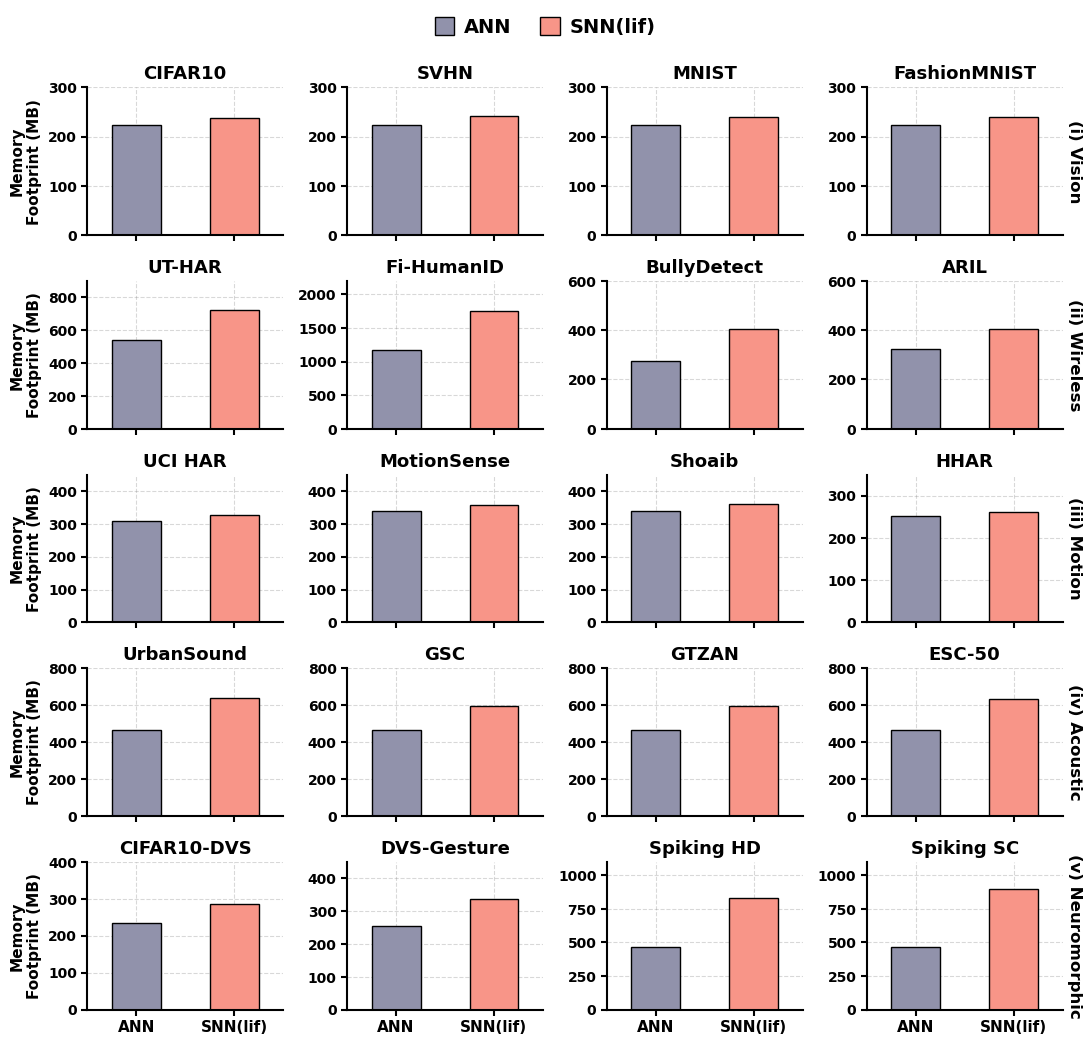

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter

fig, axs = plt.subplots(5, 4, figsize=(11, 10))

categories = ['ANN', 'SNN(lif)']
x = np.arange(len(categories))

colors = ['#9192ab', '#f89588'] 

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

BAR_WIDTH = 0.5  

for row in range(5):
    for col in range(4):
        ax = axs[row][col]

        if col == 0:
            ax.set_ylabel('Memory\nFootprint (MB)', fontweight='bold', fontsize=11, color='black')

        if col == 3:
            ax_right = ax.twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)
            ax_right.spines['bottom'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[row]}', fontweight='bold', fontsize=12, rotation=-90, color='black')
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        ax.tick_params(axis='x', which='both', bottom=True, top=False, 
                       colors='black', width=1.5, length=4, direction='out')
        ax.tick_params(axis='y', which='both', left=True, right=False, 
                       colors='black', width=1.5, length=4, direction='out')
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')
            label.set_color('black')

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_color('black')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

        ax.set_xticks([0, 1]) 
        ax.set_xlim(-0.5, 1.5)  

        if row == 4: 
            ax.set_xticklabels(categories, fontsize=11, fontweight='bold', color='black', 
                               rotation=0)
        else:
            ax.set_xticklabels([])

titles = [
    ['CIFAR10', 'SVHN', 'MNIST', 'FashionMNIST'],               
    ['UT-HAR', 'Fi-HumanID', 'BullyDetect', 'ARIL'],            
    ['UCI HAR', 'MotionSense', 'Shoaib', 'HHAR'],              
    ['UrbanSound', 'GSC', 'GTZAN', 'ESC-50'],                  
    ['CIFAR10-DVS', 'DVS-Gesture', 'Spiking HD', 'Spiking SC']  
]

for r in range(5):
    for c in range(4):
        axs[r][c].set_title(titles[r][c], fontweight='bold', fontsize=13, color='black')

def plot_pair(ax, ann_val, snn_val):
    ax.bar(0, ann_val, width=BAR_WIDTH, color=colors[0], edgecolor='black', linewidth=1.0, zorder=2)
    ax.bar(1, snn_val, width=BAR_WIDTH, color=colors[1], edgecolor='black', linewidth=1.0, zorder=2)


# Row 0: Vision
axs[0][0].set_ylim(0, 300)
plot_pair(axs[0][0], 223.86, 237.94)
axs[0][1].set_ylim(0, 300)
plot_pair(axs[0][1], 224.38, 241.11)
axs[0][2].set_ylim(0, 300)
plot_pair(axs[0][2], 224.24, 239)
axs[0][3].set_ylim(0, 300)
plot_pair(axs[0][3], 224.16, 239.57)

# Row 1: Wireless
axs[1][0].set_ylim(0, 900)
plot_pair(axs[1][0], 542.88, 720.6)
axs[1][1].set_ylim(0, 2200)
plot_pair(axs[1][1], 1174.66, 1759.98)
axs[1][2].set_ylim(0, 600)
plot_pair(axs[1][2], 276.08, 405.82)
axs[1][3].set_ylim(0, 600)
plot_pair(axs[1][3], 324.39, 403.08)

# Row 2: Motion===
axs[2][0].set_ylim(0, 450)
plot_pair(axs[2][0], 309.73, 326.43)
axs[2][1].set_ylim(0, 450)
plot_pair(axs[2][1], 337.81, 356.82)
axs[2][2].set_ylim(0, 450)
plot_pair(axs[2][2], 338.12, 361.31)
axs[2][3].set_ylim(0, 350)
plot_pair(axs[2][3], 252.11, 261.78)

# Row 3: Acoustic ===
axs[3][0].set_ylim(0, 800)
plot_pair(axs[3][0], 464.24, 640.93)
axs[3][1].set_ylim(0, 800)
plot_pair(axs[3][1], 466.2, 594.13)
axs[3][2].set_ylim(0, 800)
plot_pair(axs[3][2], 465.18, 593.33)
axs[3][3].set_ylim(0, 800)
plot_pair(axs[3][3], 465.93, 635.27)

# Row 4: Neuromorphic
axs[4][0].set_ylim(0, 400)
plot_pair(axs[4][0], 234.7, 286.11)
axs[4][1].set_ylim(0, 450)
plot_pair(axs[4][1], 255.98, 337.35)
axs[4][2].set_ylim(0, 1100)
plot_pair(axs[4][2], 465.95, 833.8)
axs[4][3].set_ylim(0, 1100)
plot_pair(axs[4][3], 466.04, 898.14)

legend_patches = [
    mpatches.Patch(facecolor=colors[0], edgecolor='black', linewidth=1.0, label='ANN'),
    mpatches.Patch(facecolor=colors[1], edgecolor='black', linewidth=1.0, label='SNN(lif)')
]

fig.legend(
    handles=legend_patches,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=2, 
    handlelength=1,     
    handleheight=1,     
    handletextpad=0.5, 
    columnspacing=1.5, 
    prop={'weight': 'bold', 'size': 14},
    frameon=False,
)

fig.subplots_adjust(wspace=0.3)
fig.tight_layout()
plt.savefig('./cmp-footprint-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

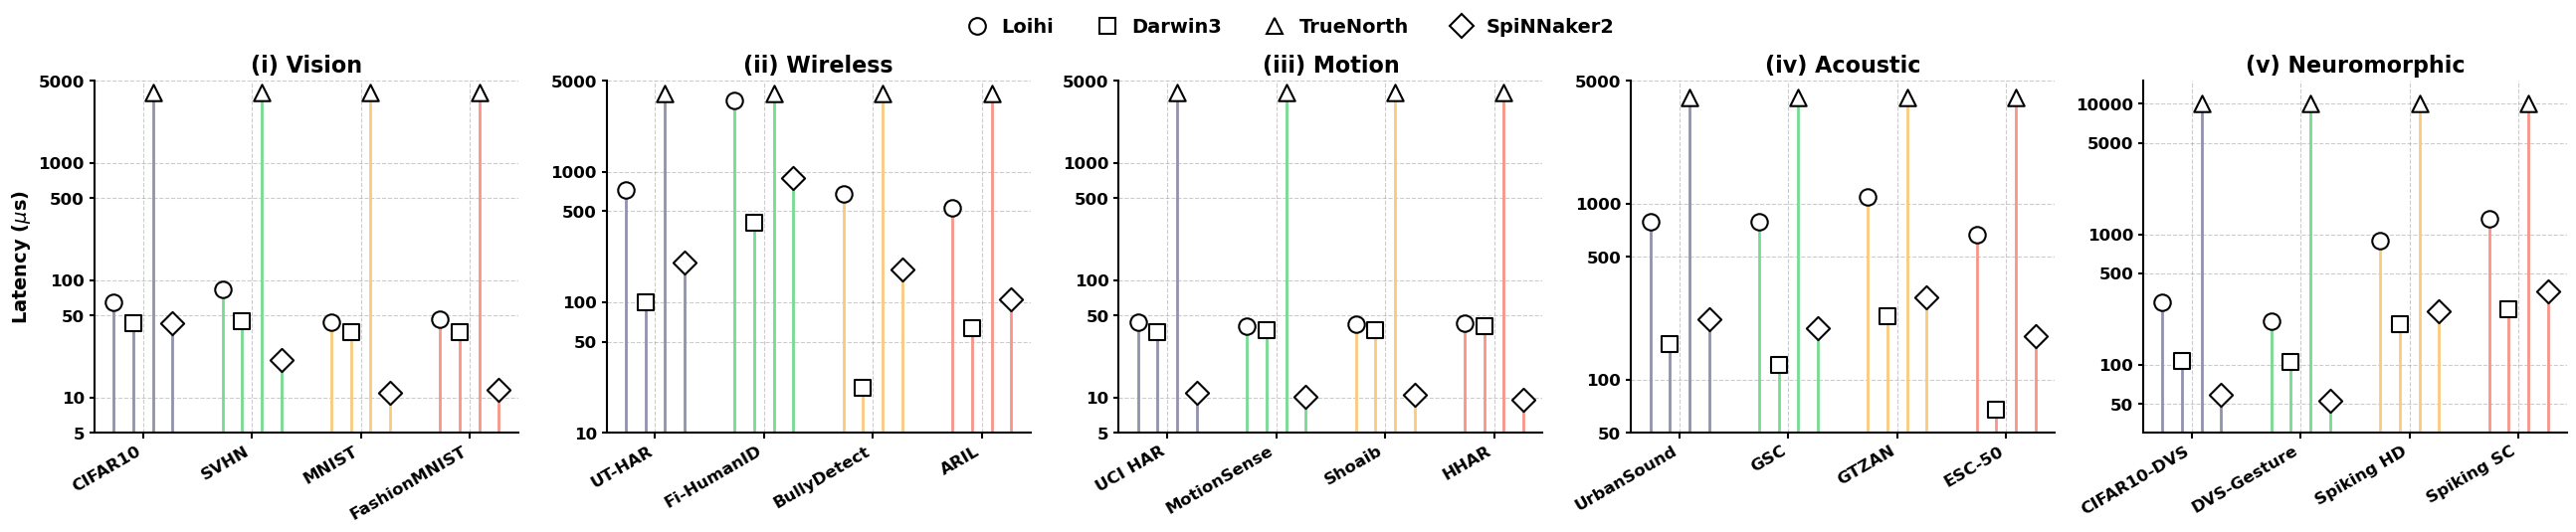

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

chips = ['Loihi', 'Darwin3', 'TrueNorth', 'SpiNNaker2']

data = {
    "Vision": {
        "CIFAR10": [64.54, 43.31, 4000, 43.31],
        "SVHN": [83.91, 44.98, 4000, 20.98],
        "MNIST": [43.97, 36.34, 4000, 10.99],
        "FashionMNIST": [46.19, 36.33, 4000, 11.55]
    },
    "Wireless": {
        "UT-HAR": [731.6, 100.08, 4000, 202.27],
        "Fi-HumanID": [3540.63, 405.63, 4000, 906.60],
        "BullyDetect": [675.09, 22.12, 4000, 180.13],
        "ARIL": [528.5, 64.11, 4000, 106.10]
    },
    "Motion": {
        "UCI HAR": [43.51, 36.37, 4000, 10.88],
        "MotionSense": [40.91, 37.87, 4000, 10.23],
        "Shoaib": [42.33, 37.87, 4000, 10.58],
        "HHAR": [42.82, 40.52, 4000, 9.61]
    },
    "Acoustic": {
        "UrbanSound": [796.31, 160.53, 4000, 220.88],
        "GSC": [792.58, 121.39, 4000, 197.98],
        "GTZAN": [1093.01, 229.76, 4000, 295.01],
        "ESC-50": [665.71, 68.08, 4000, 178.21]
    },
    "Neuromorphic": {
        "CIFAR10-DVS": [301.4, 107.08, 10000, 59.00],
        "DVS-Gesture": [216.37, 105.82, 10000, 52.57],
        "Spiking HD": [887.84, 203.19, 10000, 255.55],
        "Spiking SC": [1322.38, 268.45, 10000, 368.05]
    }
}

marker_color = 'white'

line_colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588']

chip_markers = ['o', 's', '^', 'D']

modalities = list(data.keys())

modality_titles = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

y_axis_config = {
    "Vision": {
        "ylim": (5, 5000),
        "yticks": [5, 10, 50, 100, 500, 1000, 5000]
    },
    "Wireless": {
        "ylim": (10, 5000),
        "yticks": [10, 50, 100, 500, 1000, 5000]
    },
    "Motion": {
        "ylim": (5, 5000),
        "yticks": [5, 10, 50, 100, 500, 1000, 5000]
    },
    "Acoustic": {
        "ylim": (50, 5000),
        "yticks": [50, 100, 500, 1000, 5000]
    },
    "Neuromorphic": {
        "ylim": (30, 15000),
        "yticks": [50, 100, 500, 1000, 5000, 10000]
    }
}

fig, axs = plt.subplots(1, 5, figsize=(26, 5))

bar_width = 0.18

for col_idx, modality in enumerate(modalities):
    ax = axs[col_idx]
    datasets = list(data[modality].keys())
    x = np.arange(len(datasets))
    
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.4, zorder=0)
    
    ax.set_title(modality_titles[col_idx], fontweight='bold', fontsize=16, color='black')
    
    config = y_axis_config[modality]
    ymin = config["ylim"][0]
    
    for dataset_idx, dataset in enumerate(datasets):
        values = data[modality][dataset]
        
        for chip_idx, chip in enumerate(chips):
            val = values[chip_idx]
            
            offset = (chip_idx - 1.5) * bar_width
            xpos = dataset_idx + offset
            
            ax.vlines(xpos, ymin=ymin, ymax=val,
                      color=line_colors[dataset_idx],
                      linewidth=2,
                      zorder=2)
            
            ax.scatter(xpos, val,
                       s=140,
                       color=marker_color,
                       edgecolor='black',
                       linewidth=1.5,
                       marker=chip_markers[chip_idx],
                       zorder=3)
    
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=12, fontweight='bold', color='black', 
                      rotation=30, ha='right')
    ax.tick_params(axis='x', colors='black', width=1.5, length=4, direction='out', 
                  top=False, bottom=True)
    
    ax.set_yscale('log')
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    
    ax.minorticks_off()
    ax.tick_params(axis='y', which='major', colors='black', width=1.5)
    
    for label in ax.get_yticklabels():
        label.set_fontsize(12)       
        label.set_fontweight('bold')
        label.set_color('black')
    
    if col_idx == 0:
        ax.set_ylabel(r'Latency ($\mu$s)', fontweight='bold', fontsize=14, color='black')

chip_legend_elements = [Line2D([0], [0], color='black', marker=chip_markers[i], 
                                markersize=12, markerfacecolor='white',
                                markeredgecolor='black', markeredgewidth=1.5,
                                linewidth=0, label=chip)
                        for i, chip in enumerate(chips)]

fig.legend(
    handles=chip_legend_elements,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.08), 
    ncol=4, 
    handlelength=1.5,  
    handletextpad=0.5, 
    columnspacing=2,
    prop={'weight': 'bold', 'size': 14},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-latency-sensing-device.pdf', dpi=300, bbox_inches='tight')
plt.show()

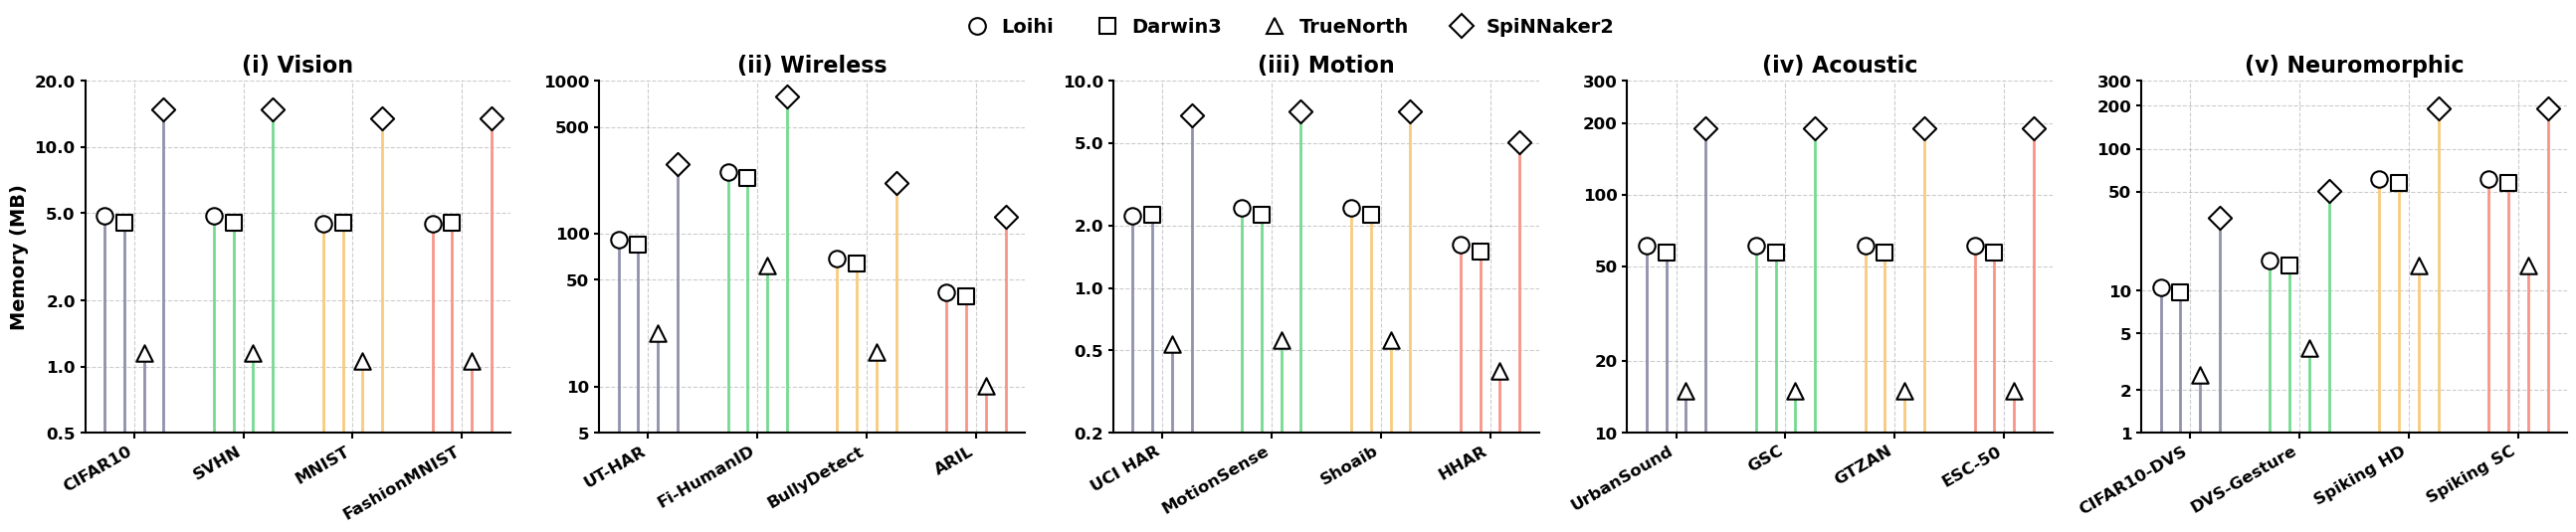

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

chips = ['Loihi', 'Darwin3', 'TrueNorth', 'SpiNNaker2']

data = {
    "Vision": {
        "CIFAR10": [4992, 4608, 1185.75, 15118.31],
        "SVHN": [4992, 4608, 1185.75, 15118.31],
        "MNIST": [4576, 4608, 1083.75, 13817.81],
        "FashionMNIST": [4576, 4608, 1083.75, 13817.81]
    },
    "Wireless": {
        "UT-HAR": [93392, 86784, 22886.25, 291799.69],
        "Fi-HumanID": [258752, 238848, 63444, 808911],
        "BullyDetect": [70720, 65280, 17340, 221085],
        "ARIL": [42640, 39936, 10455, 133301.25]
    },
    "Motion": {
        "UCI HAR": [2288, 2304, 548.25, 6990.19],
        "MotionSense": [2496, 2304, 573.75, 7315.31],
        "Shoaib": [2496, 2304, 573.75, 7315.31],
        "HHAR": [1664, 1536, 408, 5202]
    },
    "Acoustic": {
        "UrbanSound": [62608, 58368, 15312.75, 195237.56],
        "GSC": [62608, 58368, 15312.75, 195237.56],
        "GTZAN": [62608, 58368, 15312.75, 195237.56],
        "ESC-50": [62608, 58368, 15312.75, 195237.56]
    },
    "Neuromorphic": {
        "CIFAR10-DVS": [10816, 9984, 2613.75, 33325.31],
        "DVS-Gesture": [16640, 15360, 4041.75, 51532.31],
        "Spiking HD": [62608, 58368, 15312.75, 195237.56],
        "Spiking SC": [62608, 58368, 15312.75, 195237.56]
    }
}

marker_color = 'white'

line_colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588']

chip_markers = ['o', 's', '^', 'D']

modalities = list(data.keys())

modality_titles = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']

y_axis_config = {
    "Vision": {
        "ylim": (0.5, 20),
        "yticks": [0.5, 1, 2, 5, 10, 20]
    },
    "Wireless": {
        "ylim": (5, 1000),
        "yticks": [5, 10, 50, 100, 500, 1000]
    },
    "Motion": {
        "ylim": (0.2, 10),
        "yticks": [0.2, 0.5, 1, 2, 5, 10]
    },
    "Acoustic": {
        "ylim": (10, 300),
        "yticks": [10, 20, 50, 100, 200, 300]
    },
    "Neuromorphic": {
        "ylim": (1, 300),
        "yticks": [1, 2, 5, 10, 50, 100, 200, 300]
    }
}

fig, axs = plt.subplots(1, 5, figsize=(26, 5))

bar_width = 0.18

for col_idx, modality in enumerate(modalities):
    ax = axs[col_idx]
    datasets = list(data[modality].keys())
    x = np.arange(len(datasets))
    
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.4, zorder=0)
    
    ax.set_title(modality_titles[col_idx], fontweight='bold', fontsize=16, color='black')
    
    config = y_axis_config[modality]
    ymin = config["ylim"][0]
    
    for dataset_idx, dataset in enumerate(datasets):
        values = data[modality][dataset]
        
        for chip_idx, chip in enumerate(chips):
            val = values[chip_idx] / 1024 
            
            offset = (chip_idx - 1.5) * bar_width
            xpos = dataset_idx + offset
            
            ax.vlines(xpos, ymin=ymin, ymax=val,
                      color=line_colors[dataset_idx],
                      linewidth=2,
                      zorder=2)
            
            ax.scatter(xpos, val,
                       s=140,
                       color=marker_color,
                       edgecolor='black',
                       linewidth=1.5,
                       marker=chip_markers[chip_idx],
                       zorder=3)
    
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=12, fontweight='bold', color='black', 
                      rotation=30, ha='right')
    ax.tick_params(axis='x', colors='black', width=1.5, length=4, direction='out', 
                  top=False, bottom=True)
    
    ax.set_yscale('log')
    ax.set_ylim(config["ylim"])
    ax.set_yticks(config["yticks"])
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    
    ax.minorticks_off()
    ax.tick_params(axis='y', which='major', colors='black', width=1.5)
    
    for label in ax.get_yticklabels():
        label.set_fontsize(12)       
        label.set_fontweight('bold')
        label.set_color('black')
    
    if col_idx == 0:
        ax.set_ylabel('Memory (MB)', fontweight='bold', fontsize=14, color='black')

chip_legend_elements = [Line2D([0], [0], color='black', marker=chip_markers[i], 
                                markersize=12, markerfacecolor='white',
                                markeredgecolor='black', markeredgewidth=1.5,
                                linewidth=0, label=chip)
                        for i, chip in enumerate(chips)]

fig.legend(
    handles=chip_legend_elements,
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.08),
    ncol=4, 
    handlelength=1.5,  
    handletextpad=0.5, 
    columnspacing=2,
    prop={'weight': 'bold', 'size': 14},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-memory-sensing-device.pdf', dpi=300, bbox_inches='tight')
plt.show()